#Part 1: Information-theoretic measures and cross-validation

##Exercise 1.1: Graph the posterior distribution of θ for each model

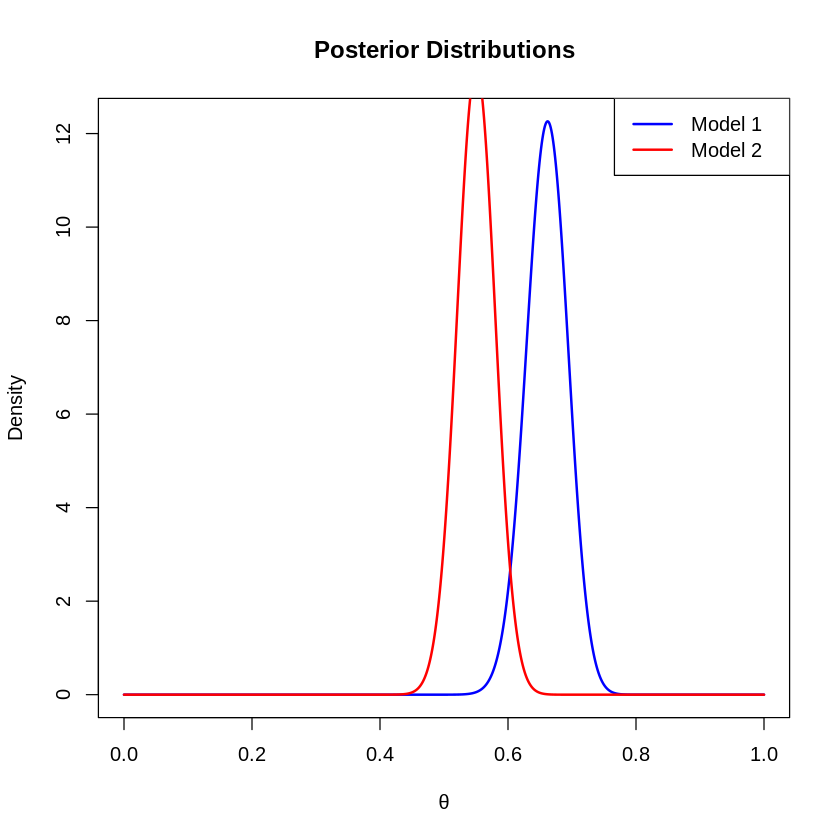

In [ ]:
y <- c(10, 15, 15, 14, 14, 14, 13, 11, 12, 16)
n <- 20

# Posterior parameters for Model 1 (Prior: Beta(6,6))
alpha1_post <- 6 + sum(y)
beta1_post <- 6 + sum(n - y)

# Posterior parameters for Model 2 (Prior: Beta(20,60))
alpha2_post <- 20 + sum(y)
beta2_post <- 60 + sum(n - y)

# Graphing
theta_seq <- seq(0, 1, length.out = 1000)
post1 <- dbeta(theta_seq, alpha1_post, beta1_post)
post2 <- dbeta(theta_seq, alpha2_post, beta2_post)

plot(theta_seq, post1, type = "l", col = "blue", lwd = 2,
     ylab = "Density", xlab = expression(theta), main = "Posterior Distributions")
lines(theta_seq, post2, col = "red", lwd = 2)
legend("topright", legend = c("Model 1", "Model 2"), col = c("blue", "red"), lwd = 2)

##Exercise 1.2: Compute log pointwise predictive density (lppd) for each model

In [ ]:
set.seed(42)
N_samples <- 10000
samples_m1 <- rbeta(N_samples, alpha1_post, beta1_post)
samples_m2 <- rbeta(N_samples, alpha2_post, beta2_post)

compute_lppd <- function(data_points, trials, post_samples) {
  sum(log(sapply(data_points, function(yi) mean(dbinom(yi, size = trials, prob = post_samples)))))
}

lppd_m1 <- compute_lppd(y, n, samples_m1)
lppd_m2 <- compute_lppd(y, n, samples_m2)

c(LPPD_M1 = lppd_m1, LPPD_M2 = lppd_m2)

LPPD_M1   LPPD_M2 
-20.36982 -25.91848

##Exercise 1.3: Calculate in-sample deviance for each model

**Why are we calling this in-sample deviance?** It is "in-sample" because the predictive accuracy is evaluated on the exact same data points that were used to fit the model's posterior distribution.

In [ ]:
dev_m1 <- -2 * lppd_m1
dev_m2 <- -2 * lppd_m2

c(Deviance_M1 = dev_m1, Deviance_M2 = dev_m2)

Deviance_M1 Deviance_M2 
   40.73964    51.83695

##Exercise 1.4: Based on in-sample deviance, which model is a better fit to the data?

Model 1 is a better fit because it has a lower in-sample deviance.

##Exercise 1.5: Out-of-sample prediction

In [ ]:
new_y <- c(5, 6, 10, 8, 9)

lppd_out_m1 <- compute_lppd(new_y, n, samples_m1)
lppd_out_m2 <- compute_lppd(new_y, n, samples_m2)

dev_out_m1 <- -2 * lppd_out_m1
dev_out_m2 <- -2 * lppd_out_m2

c(Out_Deviance_M1 = dev_out_m1, Out_Deviance_M2 = dev_out_m2)

Out_Deviance_M1 Out_Deviance_M2 
       50.47264        31.52461

Model 2 is better at predicting the new data because it has a lower out-of-sample deviance.

##Exercise 1.6: Perform leave-one-out cross-validation (LOO-CV) to compare model 1 and model 2

In [ ]:
loo_cv <- function(data_points, trials, prior_a, prior_b) {
  lpd_loo <- numeric(length(data_points))
  for (i in seq_along(data_points)) {
    y_train <- data_points[-i]
    a_post <- prior_a + sum(y_train)
    b_post <- prior_b + sum(trials - y_train)

    post_samples <- rbeta(N_samples, a_post, b_post)
    lpd_loo[i] <- log(mean(dbinom(data_points[i], size = trials, prob = post_samples)))
  }
  return(-2 * sum(lpd_loo))
}

loo_dev_m1 <- loo_cv(y, n, 6, 6)
loo_dev_m2 <- loo_cv(y, n, 20, 60)

c(LOO_Deviance_M1 = loo_dev_m1, LOO_Deviance_M2 = loo_dev_m2)

LOO_Deviance_M1 LOO_Deviance_M2 
       42.21590        54.44395

#Part 2: Marginal likelihood and prior sensitivity

##Exercise 2.1: Calculate marginal likelihood of the models

In [ ]:
ML_binomial <- function(k, n, a, b){
  term1 <- factorial(n) / (factorial(k) * factorial(n-k))
  term2 <- (factorial(k+a-1) * factorial(n-k+b-1)) / factorial(n+a+b-1)
  return(term1 * term2)
}

priors <- list(c(0.1, 0.4), c(1, 1), c(2, 6), c(6, 2), c(20, 60), c(60, 20))

# Calculate ML for k=2, n=10 across all priors
sapply(priors, function(p) ML_binomial(2, 10, p[1], p[2]))

[1] 4.739564e-01 9.090909e-02 4.726891e-03 2.313863e-04 5.079397e-21
[6] 1.506630e-23

##Exercise 2.2: Estimate the marginal likelihood of the model given the above prior assumptions using Monte Carlo Integration method

In [10]:
mc_marginal_likelihood <- function(k, n, a, b, N = 100000) {
  prior_samples <- rbeta(N, a, b)
  mean(dbinom(k, size = n, prob = prior_samples))
}

set.seed(123)

# Estimate ML for k=2, n=10 across all priors
sapply(priors, function(p) mc_marginal_likelihood(2, 10, p[1], p[2]))

[1] 0.0398041725 0.0906857755 0.1985172489 0.0096235500 0.2693406840
[6] 0.0008027328